First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionL

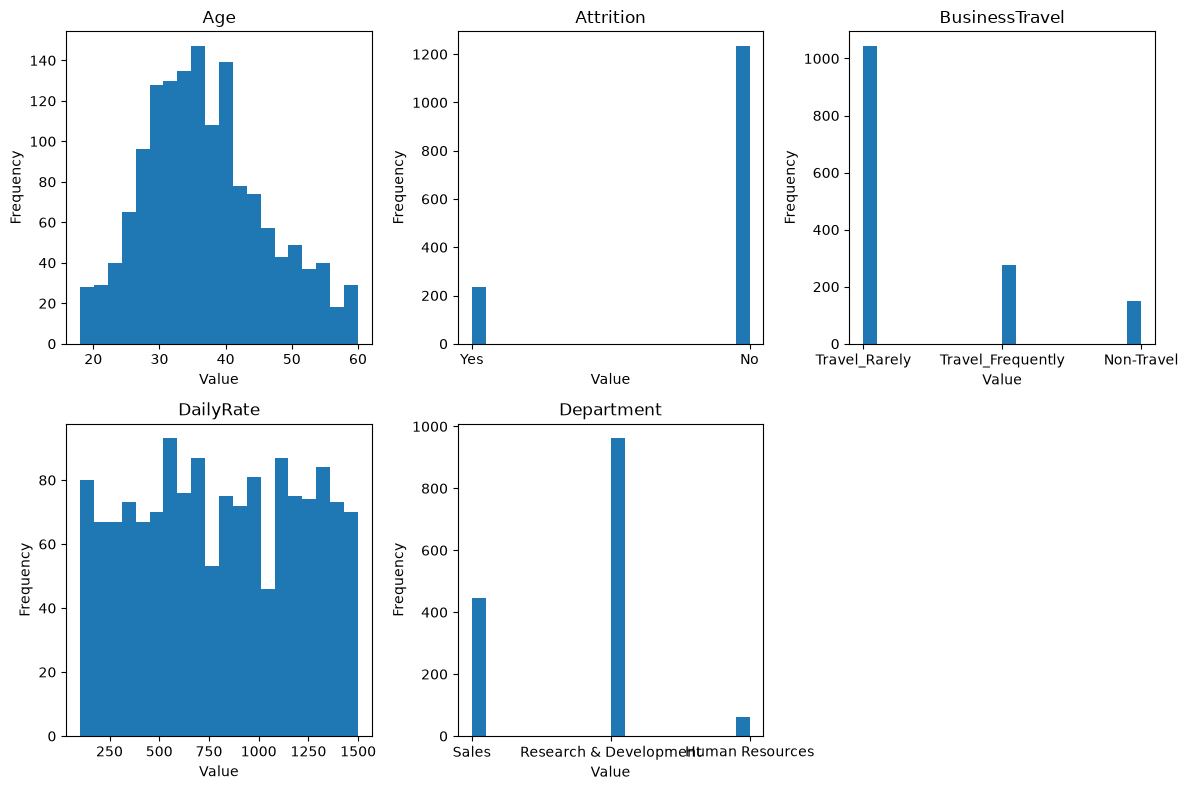


Logistic Regression Accuracy:
0.8684807256235828

Logistic Regression F1 Score:
0.4528301886792453

Logistic Regression Confusion Matrix:
[[359  21]
 [ 37  24]]

Decision Tree Accuracy:
0.7981859410430839

Decision Tree F1 Score:
0.32061068702290074

Decision Tree Confusion Matrix:
[[331  49]
 [ 40  21]]

Random Forest Accuracy:
0.8707482993197279

Random Forest F1 Score:
0.19718309859154928

Random Forest Confusion Matrix:
[[377   3]
 [ 54   7]]


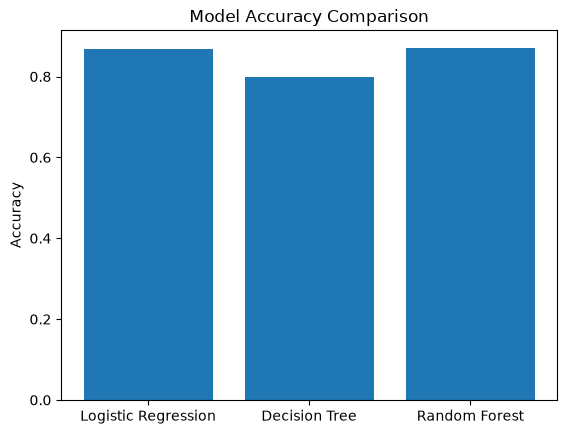


Logistic Regression Feature Importance:
                             Feature  Importance
43                      OverTime_Yes    0.948167
34     JobRole_Laboratory Technician    0.771507
23  BusinessTravel_Travel_Frequently    0.751185
42              MaritalStatus_Single    0.730499
16                 TotalWorkingYears    0.720755
20                YearsInCurrentRole    0.674094
19                    YearsAtCompany    0.646545
11                NumCompaniesWorked    0.598777
24      BusinessTravel_Travel_Rarely    0.491962
40      JobRole_Sales Representative    0.482083

Decision Tree Feature Importance:
                    Feature  Importance
9             MonthlyIncome    0.112228
43             OverTime_Yes    0.074690
1                 DailyRate    0.070414
0                       Age    0.067650
16        TotalWorkingYears    0.065314
17    TrainingTimesLastYear    0.061264
5                HourlyRate    0.057423
20       YearsInCurrentRole    0.048444
2          DistanceFromHo

In [11]:
# LAB 07 - EMPLOYEE ATTRITION ANALYZER
# Roll No 24F-AI-064

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

#------------------------------------
df = pd.read_csv("Employee.csv")
# Dataset Cleaning
print("First 5 rows:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nStatistics:")
print(df.describe())


df = df.drop([
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
], axis=1)


print("\nMissing Values:")
print(df.isnull().sum())

df = df.dropna()

# Visulaization
features = df.columns[:5]

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features):
    plt.subplot(2, 3, i + 1)
    plt.hist(df[feature], bins=20)
    plt.title(feature)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# 5. Prepare Data

X = df.drop("Attrition", axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(X, drop_first=True)


# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Fitting
model1 = LogisticRegression()
model1.fit(X_train_scaled, y_train)

y_pred1 = model1.predict(X_test_scaled)
# Perfomance Metrics
print("\nLogistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred1))

print("\nLogistic Regression F1 Score:")
print(f1_score(y_test, y_pred1))

print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred1))


model2 = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
# Choose Gini becuase its faster and doesnot use logaroth
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("\nDecision Tree Accuracy:")
print(accuracy_score(y_test, y_pred2))

print("\nDecision Tree F1 Score:")
print(f1_score(y_test, y_pred2))

print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred2))


model3 = RandomForestClassifier()

model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, y_pred3))

print("\nRandom Forest F1 Score:")
print(f1_score(y_test, y_pred3))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred3))

# Comparsion of models through barchart
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    accuracy_score(y_test, y_pred1),
    accuracy_score(y_test, y_pred2),
    accuracy_score(y_test, y_pred3)
]

plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


#Feature Importance

logistic_importance = abs(model1.coef_[0])

Decision_importance = model2.feature_importances_

Forest_importance = model3.feature_importances_


logistic_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": logistic_importance
}).sort_values("Importance", ascending=False)

Decision_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": Decision_importance
}).sort_values("Importance", ascending=False)

Forest_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": Forest_importance
}).sort_values("Importance", ascending=False)


print("\nLogistic Regression Feature Importance:")
print(logistic_df.head(10))

print("\nDecision Tree Feature Importance:")
print(Decision_df.head(10))

print("\nRandom Forest Feature Importance:")
print(Forest_df.head(10))
